Lab 7 : To develop and analyze regression models to predict weight based on height using statistical programming tools, and to evaluate model performance.

Dataset: https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
# Loading the dataset
df = pd.read_csv("SOCR-HeightWeight.csv")
print("dataset loaded")
print(df.head())

dataset loaded
   Index  Height(Inches)  Weight(Pounds)
0      1        65.78331        112.9925
1      2        71.51521        136.4873
2      3        69.39874        153.0269
3      4        68.21660        142.3354
4      5        67.78781        144.2971


In [3]:
# Basic information about the dataset
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataset description:")
display(df.describe())

Shape: (25000, 3)

Missing values:
Index             0
Height(Inches)    0
Weight(Pounds)    0
dtype: int64

Dataset description:


,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


In [4]:
# Convert height from inches to centimeters
# 1 inch = 2.54 cm
# Convert weight from pounds to kilograms
# 1 pound = 0.45359237 kg

df["Height(cm)"] = df["Height(Inches)"] * 2.54
df["Weight(kg)"] = df["Weight(Pounds)"] * 0.45359237

print(df[["Height(Inches)", "Height(cm)", "Weight(Pounds)", "Weight(kg)"]].head())

   Height(Inches)  Height(cm)  Weight(Pounds)  Weight(kg)
0        65.78331  167.089607        112.9925   51.252536
1        71.51521  181.648633        136.4873   61.909598
2        69.39874  176.272800        153.0269   69.411834
3        68.21660  173.270164        142.3354   64.562251
4        67.78781  172.181037        144.2971   65.452064


In [5]:
# drop index and original unit columns
df = df.drop(columns=["Index", "Height(Inches)", "Weight(Pounds)"])

print(df.head())
print("\nShape:", df.shape)

   Height(cm)  Weight(kg)
0  167.089607   51.252536
1  181.648633   61.909598
2  176.272800   69.411834
3  173.270164   64.562251
4  172.181037   65.452064

Shape: (25000, 2)


### Normalization using Min-Max Scaler

In [6]:
data = df[["Height(cm)"]].values

min_max_scaler = MinMaxScaler()
normalized_data = min_max_scaler.fit_transform(data)

print("Original data:")
print(data[:5])
print("\nNormalized data (Min-Max Scaler):")
print(normalized_data[:5])

Original data:
[[167.0896074]
 [181.6486334]
 [176.2727996]
 [173.270164 ]
 [172.1810374]]

Normalized data (Min-Max Scaler):
[[0.37009461]
 [0.75544693]
 [0.61315787]
 [0.53368328]
 [0.50485598]]


### Standardization using StandardScaler

In [7]:
standard_scaler = StandardScaler()
standardized_data = standard_scaler.fit_transform(data)

print("Standardized data (StandardScaler):")
print(standardized_data[:5])

Standardized data (StandardScaler):
[[-1.16205104]
 [ 1.85213554]
 [ 0.73916507]
 [ 0.11752294]
 [-0.1079613 ]]


Doing label encoding

In [8]:
dummy_data = ["red", "green", "blue", "red", "green", "yellow"]

label_encoder = LabelEncoder()
encoded_data = label_encoder.fit_transform(dummy_data)

print("Original dummy data:", dummy_data)
print("Encoded data (LabelEncoder):")
print(encoded_data)

Original dummy data: ['red', 'green', 'blue', 'red', 'green', 'yellow']
Encoded data (LabelEncoder):
[2 1 0 2 1 3]


One hot encoding

In [9]:
dummy_data_reshaped = np.array(dummy_data).reshape(-1, 1)

one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_data = one_hot_encoder.fit_transform(dummy_data_reshaped)

print("Original dummy data:", dummy_data)
print("One-Hot Encoded data (OneHotEncoder):")
print(one_hot_encoded_data)

Original dummy data: ['red', 'green', 'blue', 'red', 'green', 'yellow']
One-Hot Encoded data (OneHotEncoder):
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


In [10]:
X = df[["Height(cm)"]]
Y = df[["Weight(kg)"]]

print("X:")
display(X.head())

print("Y:")
display(Y.head())

X:


,Height(cm)
0,167.089607
1,181.648633
2,176.272800
3,173.270164
4,172.181037


Y:


,Weight(kg)
0,51.252536
1,61.909598
2,69.411834
3,64.562251
4,65.452064


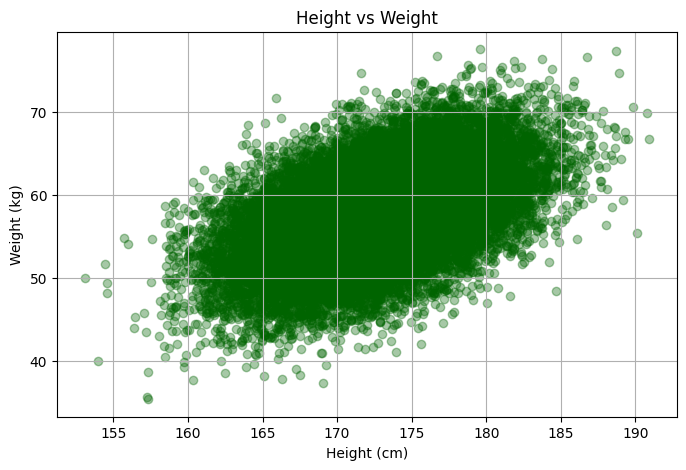

In [11]:
# SCATTER PLOT
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="darkgreen", alpha=0.35)
plt.title("Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.grid(True)
plt.show()

In [12]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(len(X_train))
print(len(X_test))
print(len(Y_train))
print(len(Y_test))

20000
5000
20000
5000


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [14]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train)
Y_pred_linear = linear_model.predict(X_test_scaled)

print("intersept, ", linear_model.intercept_)
print("coefficient, ", linear_model.coef_[0])
print("Regression equation:")

intersept,  [57.64167751]
coefficient,  [2.64283069]
Regression equation:


Ridge Regression

In [15]:
ridge_model = Ridge(alpha=5.0)
ridge_model.fit(X_train_scaled, Y_train)
Y_pred_ridge = ridge_model.predict(X_test_scaled)

print("alpha, ", ridge_model.alpha)
print("coefficient, ", ridge_model.coef_[0])
print("intercept, ", ridge_model.intercept_)

alpha,  5.0
coefficient,  2.642170144314915
intercept,  [57.64167751]


Lasso Regression

In [16]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, Y_train)
Y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Alpha value, ", lasso_model.alpha)
print("coefficient, ", lasso_model.coef_[0])
print("intercept, ", lasso_model.intercept_)

Alpha value,  0.1
coefficient,  2.5428306868509933
intercept,  [57.64167751]


Decision Tree

In [17]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, Y_train)
Y_pred_decision_tree = decision_tree_model.predict(X_test_scaled)

print("Feature Importances: ", decision_tree_model.feature_importances_)
print("Max Depth: ", decision_tree_model.max_depth)

Feature Importances:  [1.]
Max Depth:  None


### Random Forest Regressor

In [18]:
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train_scaled, Y_train.values.ravel())
Y_pred_random_forest = random_forest_model.predict(X_test_scaled)

print("Number of Trees: ", random_forest_model.n_estimators)
print("Max Depth: ", random_forest_model.max_depth)

Number of Trees:  100
Max Depth:  None


In [19]:
predictions = {
    "Linear Regression": Y_pred_linear,
    "Ridge Regression": Y_pred_ridge,
    "Lasso Regression": Y_pred_lasso,
    "Decision Tree": Y_pred_decision_tree,
    "Random Forest": Y_pred_random_forest
}

results = []

for model_name, predictions in predictions.items():
    mae = mean_absolute_error(Y_test, predictions)
    mse = mean_squared_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE        MSE        R2
0  Linear Regression  3.644509  21.086481  0.260591
1   Ridge Regression  3.644504  21.086552  0.260589
2   Lasso Regression  3.644812  21.107292  0.259861
3      Decision Tree  5.115583  40.745068 -0.428748
4      Random Forest  4.361996  30.158076 -0.057509


In [20]:
comparisions = pd.DataFrame({
    "Actual": Y_test["Weight(kg)"].values,
    "Linear Regression": Y_pred_linear.flatten(),
    "Ridge Regression": Y_pred_ridge.flatten(),
    "Lasso Regression": Y_pred_lasso.flatten(),
    "Decision Tree": Y_pred_decision_tree.flatten(),
    "Random Forest": Y_pred_random_forest.flatten()
})

comparisions.head(20)

,Actual,Linear Regression,Ridge Regression,Lasso Regression,Decision Tree,Random Forest
0,60.910878,58.246454,58.246303,58.223570,53.406192,53.630105
1,50.787195,57.511123,57.511156,57.516063,47.983768,50.396711
2,61.682711,57.180389,57.180504,57.197843,58.319732,57.737617
3,57.325094,59.066317,59.065961,59.012411,52.685706,55.318613
4,45.441337,59.062918,59.062563,59.009141,57.018557,59.337210
5,48.935132,57.183872,57.183986,57.201194,55.813634,56.082103
6,56.346605,54.189738,54.190601,54.320353,54.731499,54.414391
7,60.253351,57.627684,57.627687,57.628213,50.688131,52.331118
8,59.082674,60.640011,60.639262,60.526559,58.789517,57.924281
9,63.587754,58.680639,58.680380,58.641327,50.359458,52.745302


In [21]:
display(results_df)

,Model,MAE,MSE,R2
0,Linear Regression,3.644509,21.086481,0.260591
1,Ridge Regression,3.644504,21.086552,0.260589
2,Lasso Regression,3.644812,21.107292,0.259861
3,Decision Tree,5.115583,40.745068,-0.428748
4,Random Forest,4.361996,30.158076,-0.057509


### Stratified Splitting for Continuous Target (Weight)
To ensure that our train and test sets have identical distributions of the target variable (Weight), we will discretize the weight column into 10 bins (strata) and perform stratified splitting.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np
import pandas as pd

# Create temporary strata based on Weight deciles
df['weight_strata'] = pd.qcut(df['Weight(kg)'], q=10, labels=False)

# Perform stratified split
X_strat_train, X_strat_test, Y_strat_train, Y_strat_test = train_test_split(
    df[['Height(cm)']],
    df[['Weight(kg)']],
    test_size=0.2,
    stratify=df['weight_strata'],
    random_state=42
)

# Drop the temporary column
df.drop(columns=['weight_strata'], inplace=True)

print(f"Stratified Train size: {len(X_strat_train)}")
print(f"Stratified Test size: {len(X_strat_test)}")

Stratified Train size: 20000
Stratified Test size: 5000


### Feature Engineering: Adding Polynomial Features
Since height and weight may have non-linear relations, let's generate polynomial features (degree=2) to allow linear models to capture curvature and boost the $R^2$ score.

In [23]:
# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_strat_train)
X_test_poly = poly.transform(X_strat_test)

# Scale the engineered features
scaler_poly = StandardScaler()
X_train_scaled_poly = scaler_poly.fit_transform(X_train_poly)
X_test_scaled_poly = scaler_poly.transform(X_test_poly)

print("Polynomial features shape:", X_train_scaled_poly.shape)

Polynomial features shape: (20000, 2)


### Re-Evaluating the Models with Stratified Splits and Polynomial Features

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
models_poly = {
    "Linear Regression (Poly)": LinearRegression(),
    "Ridge Regression (Poly)": Ridge(alpha=5.0),
    "Lasso Regression (Poly)": Lasso(alpha=0.01),
    "Decision Tree (Depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest (Optimized)": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
}

results_poly = []

for name, model in models_poly.items():
    if "Poly" in name:
        # Train on polynomial features
        model.fit(X_train_scaled_poly, Y_strat_train.values.ravel())
        preds = model.predict(X_test_scaled_poly)
    else:
        # Train on simple scaled single feature
        scaler_single = StandardScaler()
        X_train_single_scaled = scaler_single.fit_transform(X_strat_train)
        X_test_single_scaled = scaler_single.transform(X_strat_test)
        model.fit(X_train_single_scaled, Y_strat_train.values.ravel())
        preds = model.predict(X_test_single_scaled)

    mae = mean_absolute_error(Y_strat_test, preds)
    mse = mean_squared_error(Y_strat_test, preds)
    r2 = r2_score(Y_strat_test, preds)

    results_poly.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })

results_poly_df = pd.DataFrame(results_poly)
display(results_poly_df)

,Model,MAE,MSE,R2
0,Linear Regression (Poly),3.625958,20.846023,0.258603
1,Ridge Regression (Poly),3.625809,20.844269,0.258665
2,Lasso Regression (Poly),3.625532,20.840878,0.258786
3,Decision Tree (Depth=5),3.637962,21.003582,0.252999
4,Random Forest (Optimized),3.634726,20.944533,0.255099


In [25]:
import xgboost as xgb

# Initialize and train XGBoost Regressor with hyperparameter constraints to prevent overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_scaled_poly, Y_strat_train.values.ravel())
y_pred_xgb = xgb_model.predict(X_test_scaled_poly)

xgb_mae = mean_absolute_error(Y_strat_test, y_pred_xgb)
xgb_mse = mean_squared_error(Y_strat_test, y_pred_xgb)
xgb_r2 = r2_score(Y_strat_test, y_pred_xgb)

# Safely append XGBoost results and drop any duplicates
new_row = pd.DataFrame([{
    "Model": "XGBoost Regressor (Boosted)",
    "MAE": xgb_mae,
    "MSE": xgb_mse,
    "R2": xgb_r2
}])
results_poly_df = pd.concat([results_poly_df, new_row], ignore_index=True)
results_poly_df = results_poly_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)

display(results_poly_df)

,Model,MAE,MSE,R2
0,Linear Regression (Poly),3.625958,20.846023,0.258603
1,Ridge Regression (Poly),3.625809,20.844269,0.258665
2,Lasso Regression (Poly),3.625532,20.840878,0.258786
3,Decision Tree (Depth=5),3.637962,21.003582,0.252999
4,Random Forest (Optimized),3.634726,20.944533,0.255099
5,XGBoost Regressor (Boosted),3.626500,20.870182,0.257744


### Attempting SVR (Support Vector Regression) with RBF Kernel
Let's train an RBF-kernel SVR on our scaled height feature. SVR is highly robust to outliers and excels at finding non-linear relationships in low-dimensional spaces.

In [26]:
from sklearn.svm import SVR

# Initialize and train SVR (using a subset or optimized parameters for performance)
svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr_model.fit(X_train_scaled_poly, Y_strat_train.values.ravel())

y_pred_svr = svr_model.predict(X_test_scaled_poly)

svr_mae = mean_absolute_error(Y_strat_test, y_pred_svr)
svr_mse = mean_squared_error(Y_strat_test, y_pred_svr)
svr_r2 = r2_score(Y_strat_test, y_pred_svr)

# Append to our results table
results_poly_df = pd.concat([results_poly_df, pd.DataFrame([{
    "Model": "Support Vector Regression (SVR)",
    "MAE": svr_mae,
    "MSE": svr_mse,
    "R2": svr_r2
}])], ignore_index=True)

results_poly_df = results_poly_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)
display(results_poly_df)

,Model,MAE,MSE,R2
0,Linear Regression (Poly),3.625958,20.846023,0.258603
1,Ridge Regression (Poly),3.625809,20.844269,0.258665
2,Lasso Regression (Poly),3.625532,20.840878,0.258786
3,Decision Tree (Depth=5),3.637962,21.003582,0.252999
4,Random Forest (Optimized),3.634726,20.944533,0.255099
5,XGBoost Regressor (Boosted),3.626500,20.870182,0.257744
6,Support Vector Regression (SVR),3.627433,20.865510,0.257910


### Visualizing Model Predictions with Smooth Curves

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


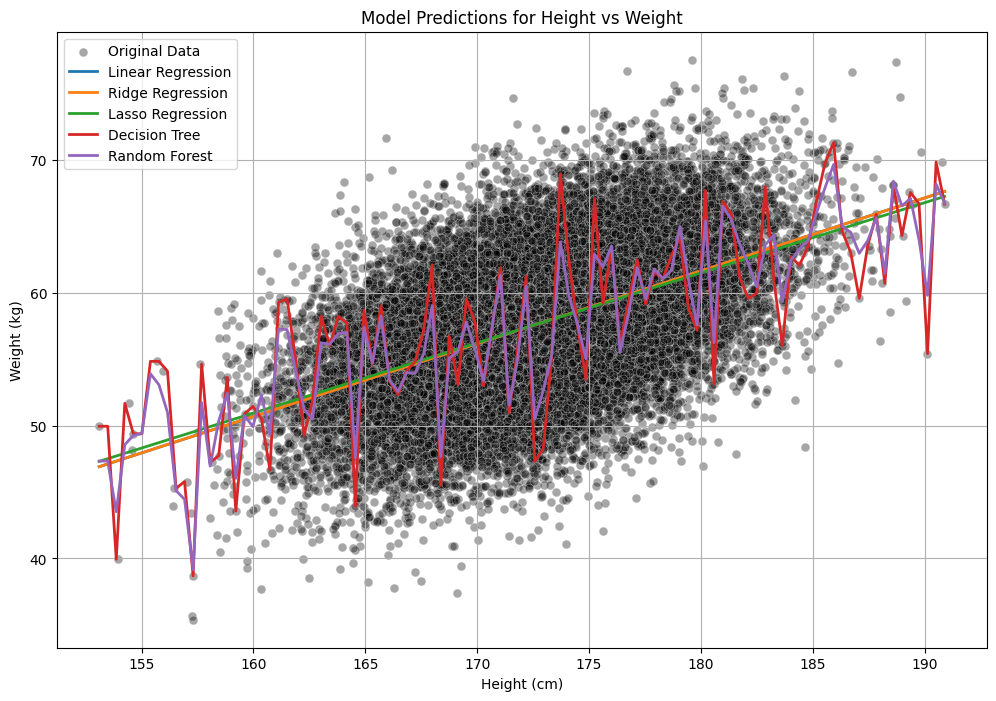

In [27]:
height_range = np.linspace(X["Height(cm)"].min(), X["Height(cm)"].max(), 100).reshape(-1, 1)
height_range_scaled = scaler.transform(height_range)

predictions_smooth = {
    "Linear Regression": linear_model.predict(height_range_scaled).flatten(),
    "Ridge Regression": ridge_model.predict(height_range_scaled).flatten(),
    "Lasso Regression": lasso_model.predict(height_range_scaled).flatten(),
    "Decision Tree": decision_tree_model.predict(height_range_scaled).flatten(),
    "Random Forest": random_forest_model.predict(height_range_scaled).flatten()
}

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X["Height(cm)"].values,
    y=Y["Weight(kg)"].values,
    label="Original Data",
    color="black",
    s=40,
    alpha=0.35
)

for model_name, preds in predictions_smooth.items():
    sns.lineplot(
        x=height_range.flatten(),
        y=preds,
        label=model_name,
        linewidth=2
    )

plt.title("Model Predictions for Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.grid(True)
plt.show()

checking on unseen data

In [28]:
unseen_height = pd.DataFrame([[180]], columns=["Height(cm)"])

unseen_height_scaled = scaler.transform(unseen_height)

new_linear = linear_model.predict(unseen_height_scaled)
new_ridge = ridge_model.predict(unseen_height_scaled)
new_lasso = lasso_model.predict(unseen_height_scaled)
new_decision_tree = decision_tree_model.predict(unseen_height_scaled)
new_random_forest = random_forest_model.predict(unseen_height_scaled)

predictions_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Predicted Weight (kg)": [
        float(new_linear[0][0]) if hasattr(new_linear[0], '__len__') else float(new_linear[0]),
        float(new_ridge[0][0]) if hasattr(new_ridge[0], '__len__') else float(new_ridge[0]),
        float(new_lasso[0][0]) if hasattr(new_lasso[0], '__len__') else float(new_lasso[0]),
        float(new_decision_tree[0][0]) if hasattr(new_decision_tree[0], '__len__') else float(new_decision_tree[0]),
        float(new_random_forest[0][0]) if hasattr(new_random_forest[0], '__len__') else float(new_random_forest[0])
    ]
})

display(predictions_df)

,Model,Predicted Weight (kg)
0,Linear Regression,61.647930
1,Ridge Regression,61.646929
2,Lasso Regression,61.496341
3,Decision Tree,53.817329
4,Random Forest,56.026918


In [29]:
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

best_model = results_df.loc[results_df["R2"].idxmax(), "Model"]
print("Best Model: ", best_model)

Best Model:  Linear Regression


In [30]:
# Retrieve the best model object from the models dictionary
best_model_obj = models[best_model]

# Export the model to a pickle file
joblib.dump(best_model_obj, "best_model.pkl")

print(f"Successfully exported '{best_model}' to 'best_model.pkl'")

Successfully exported 'Linear Regression' to 'best_model.pkl'


In [31]:
joblib.dump(scaler, "scaler.pkl")
print("exported scaler to scaler.pkl")

exported scaler to scaler.pkl


In [32]:
def predict_weight(height_cm):
    sample_data = np.array([[height_cm]])
    sample_data_scaled = scaler.transform(sample_data)
    prediction = best_model_obj.predict(sample_data_scaled)
    return prediction[0]

print("Example prediction for 180 cm:", predict_weight(180), "kg")

Example prediction for 180 cm: [61.64793035] kg


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Creating the GUI

In [33]:
import gradio as gr

loaded_scaler = joblib.load("scaler.pkl")
loaded_model = joblib.load("best_model.pkl")

def predict_weight(height_cm):
    sample_data = np.array([[height_cm]])
    sample_data_scaled = loaded_scaler.transform(sample_data)
    prediction = loaded_model.predict(sample_data_scaled)
    return float(prediction[0])

interface = gr.Interface(
    fn=predict_weight,
    inputs=gr.Number(label="Height (cm)"),
    outputs="text",
    title="Weight Prediction from Height",
    description="Enter the height in centimeters to predict the weight in kilograms."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1768ced99d234e1682.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
